In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# inputs
CL = 0.95
A = 28 # target mass Si
# annual modulation fitting constants
c1 = 0.751
c2 = 0.561
m_T = A*0.938 #[GeV]
# most likely speed
v_0 = 230 #[km s-1]

# recoil energy bounds for detector, E1 = min, E2 = max
E1 = 1*10**-6 #in GeV
E2 = 100 #in GeV 

# the length and mass of the experiment data-taking
DAQday = 1
DAQkg = 1

flag_nuclear_form_factor = True
def get_Nexp_from_CL(CL = 0.95):
    return -np.log(1-CL)

In [12]:
def get_limit_contour(A = 28, v_0 = 230, E1 = 1*10**-6, E2 = 50, CL = 0.95, 
                      flag_nuclear_form_factor = True, massrange = [-1, 4], 
                      xsrange = [-4, 0], DAQday = 1, DAQkg = 1, npoints = 1000):
    contour_mass = []
    contour_xs = []
    lgmasses  = np.linspace(*massrange, npoints)
    lgxses = np.linspace(*xsrange,npoints)
    m_T = A*0.938 #[GeV]

    for i, m_D in enumerate(10**lgmasses):
        for j, xs in enumerate(10**lgxses):
            # most probable incident energy of the dark matter [GeV]
            E0 = 1/2 * m_D * (v_0/(3*10**5))**2 # in GeV
            r = 4*m_D*m_T/(m_D+m_T)**2
            R0 = 540/(A*m_D)*(xs)*1*(v_0/230) #[pb]
            if flag_nuclear_form_factor == True:
                k = c2/(E0*r) + (1/3*(6.92*10**-3)**2*A*((1.14*A)**1/3)**2) # k factor in integral, see details in note
            else:
                k = c2/(E0*r) 
            R = c1 * R0/E0/r/k * (np.exp(-k*E1) - np.exp(-k*E2)) *A*A

     
            
            if abs(R*DAQday*DAQkg - get_Nexp_from_CL(CL)) < 0.01:
                # print(R00, R01, R00/R01) # sanity check: the difference is around 10**-7
                contour_mass.append(m_D)
                contour_xs.append(xs)

    return np.array(contour_mass), np.array(contour_xs)

In [13]:
lgmasses  = np.linspace(-1, 4, 500)
lgxses = np.linspace(-1,2,500)

contour_mass = []
contour_xs = []

for i, m_D in enumerate(10**lgmasses):
    for j, xs in enumerate(10**lgxses):
        # most probable incident energy of the dark matter [GeV]
        E0 = 1/2 * m_D * (v_0/(3*10**5))**2 # in GeV
        r = 4*m_D*m_T/(m_D+m_T)**2
        R0 = 540/(A*m_D)*(xs)*1*(v_0/230) #[pb]
        if flag_nuclear_form_factor == True:
            k = c2/(E0*r) + (1/3*(6.92*10**-3)**2*A*((1.14*A)**1/3)**2) # k factor in integral, see details in note
        else:
            k = c2/(E0*r) 
        R= c1 * R0/E0/r/k * (np.exp(-k*E1) - np.exp(-k*E2))

        if abs(R-get_Nexp_from_CL(CL)) < 0.01:
            # print(R00, R01, R00/R01) # sanity check: the difference is around 10**-7
            contour_mass.append(m_D)
            contour_xs.append(xs)

In [14]:
# import damic paper data:
data = np.loadtxt("nominal.csv", delimiter=",") 
upper = np.loadtxt("upper.csv", delimiter=",") 
lower = np.loadtxt("lower.csv", delimiter=",") 

mass2, xs2 = upper[:,0], upper[:,1]*1e36
mass3, xs3 = lower[:,0], lower[:,1]*1e36
mass4, xs4 = data[:,0], data[:,1]*1e36


<Figure size 504x360 with 0 Axes>

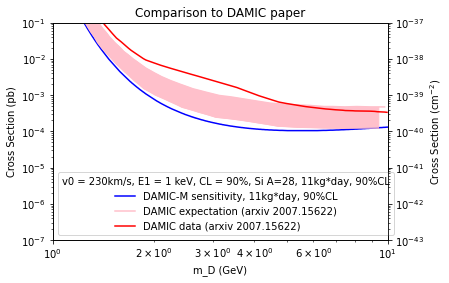

In [15]:
mass1, xs1 = get_limit_contour(A=28, E1=1*10**-6, xsrange=[-7, -1], massrange=[0, 1], DAQday=11, CL = 0.9) # 1.64485 sigma
# mass2, xs2 = get_limit_contour(A=28, E1=1*10**-6, xsrange=[-7, -1], massrange=[0, 1], DAQday=11, CL = 0.991827) # 2.64485 sigma
# mass3, xs3 = get_limit_contour(A=28, E1=1*10**-6, xsrange=[-7, -1], massrange=[0, 1], DAQday=11, CL = 0.480978) # 0.64485 sigma

plt.figure(figsize=(7, 5))
fig, ax1 = plt.subplots()
ax1.plot(mass1, xs1, label='DAMIC-M sensitivity, 11kg*day, 90%CL', color='blue')
# ax1.plot(mass1, xs1, label='DAMIC-M sensitivity (+bkg_model), 11kg*day, 90%CL', color='blue')
ax1.plot(mass2, xs2, color='pink')
# ax1.plot(mass2, xs2, label='DAMIC expectation', color='pink')

ax1.plot(mass3, xs3, label='DAMIC expectation (arxiv 2007.15622)', color='pink')
ax1.plot(mass4, xs4, label='DAMIC data (arxiv 2007.15622)', color='red')

common_mass = np.linspace(max(min(mass2), min(mass3)), min(max(mass2), max(mass3)), 500)
xs2_interp = np.interp(common_mass, mass2, xs2)
xs3_interp = np.interp(common_mass, mass3, xs3)
ax1.fill_between(common_mass, xs2_interp, xs3_interp, color='pink', alpha=1)

ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_title('Comparison to DAMIC paper')
ax1.set_xlabel('m_D (GeV)')
ax1.set_ylabel('Cross Section (pb)')
ax1.set_xlim(1,10)
ax1.set_ylim(1e-7,1e-1)

ax1.axhline(0, color='black', linewidth=0.5, linestyle="--")
ax1.axvline(0, color='black', linewidth=0.5, linestyle="--")

# second axis
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.set_ylabel(r'Cross Section (cm$^{-2}$)')
ax2.set_ylim(ax1.get_ylim()[0] * 1e-36, ax1.get_ylim()[1] * 1e-36)

ax1.legend(title='v0 = 230km/s, E1 = 1 keV, CL = 90%, Si A=28, 11kg*day, 90%CL')
plt.show()

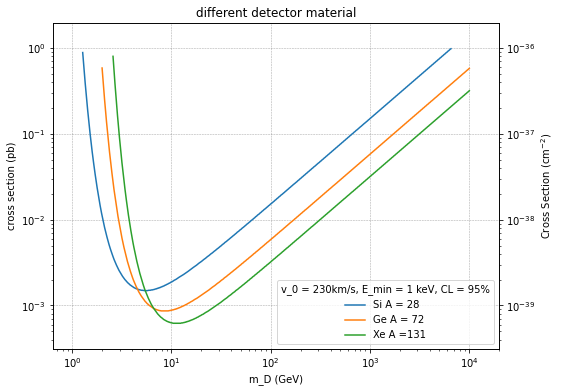

In [16]:
# different detector material
mass1, xs1 = get_limit_contour(A=28) 
mass2, xs2 = get_limit_contour(A=72) 
mass3, xs3 = get_limit_contour(A=131) 

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(mass1, xs1, label='Si A = 28')
ax1.plot(mass2, xs2, label='Ge A = 72')
ax1.plot(mass3, xs3, label='Xe A =131')

ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_title('different detector material')
ax1.set_xlabel('m_D (GeV)')
ax1.set_ylabel('cross section (pb)')
ax1.set_xlim(np.hstack([mass1, mass2, mass3]).min()/2, np.hstack([mass1, mass2, mass3]).max()*2)
ax1.set_ylim(np.hstack([xs1, xs2, xs3]).min()/2, np.hstack([xs1, xs2, xs3]).max()*2)

ax1.axhline(0, color='black', linewidth=0.5, linestyle="--")
ax1.axvline(0, color='black', linewidth=0.5, linestyle="--")
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# second axis
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.set_ylabel(r'Cross Section (cm$^{-2}$)')
ax2.set_ylim(ax1.get_ylim()[0] * 1e-36, ax1.get_ylim()[1] * 1e-36)

ax1.legend(title = 'v_0 = 230km/s, E_min = 1 keV, CL = 95%')
plt.show()

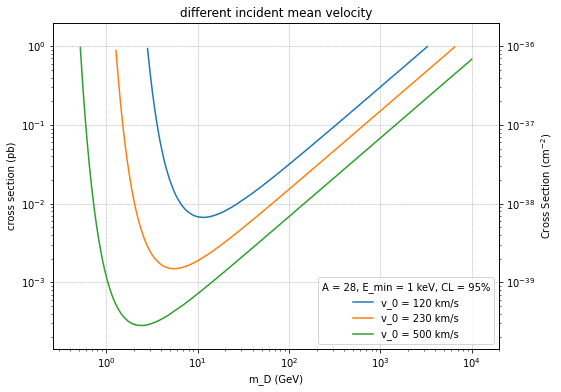

In [17]:
# different incident v_0
mass1, xs1 = get_limit_contour(v_0 = 120) 
mass2, xs2 = get_limit_contour(v_0 = 230) 
mass3, xs3 = get_limit_contour(v_0 = 500) 

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(mass1, xs1, label='v_0 = 120 km/s')
ax1.plot(mass2, xs2, label='v_0 = 230 km/s')
ax1.plot(mass3, xs3, label='v_0 = 500 km/s')

ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_title('different incident mean velocity')
ax1.set_xlabel('m_D (GeV)')
ax1.set_ylabel('cross section (pb)')
ax1.set_xlim(np.hstack([mass1, mass2, mass3]).min()/2, np.hstack([mass1, mass2, mass3]).max()*2)
ax1.set_ylim(np.hstack([xs1, xs2, xs3]).min()/2, np.hstack([xs1, xs2, xs3]).max()*2)


ax1.axhline(0, color='black', linewidth=0.5, linestyle="--")
ax1.axvline(0, color='black', linewidth=0.5, linestyle="--")
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# second axis
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.set_ylabel(r'Cross Section (cm$^{-2}$)')
ax2.set_ylim(ax1.get_ylim()[0] * 1e-36, ax1.get_ylim()[1] * 1e-36)

ax1.legend(title = 'A = 28, E_min = 1 keV, CL = 95%')
plt.show()

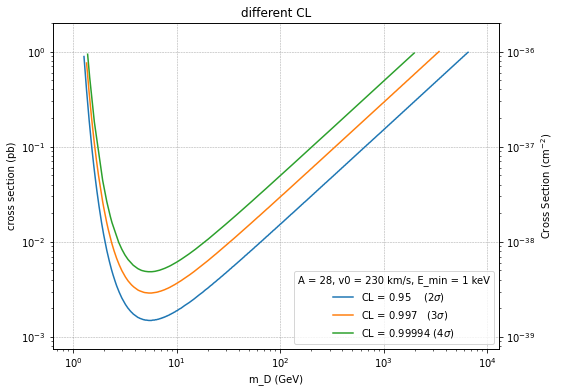

In [18]:
# different CL
mass1, xs1 = get_limit_contour(CL = 0.95, npoints = 1000) 
mass2, xs2 = get_limit_contour(CL = 0.997, npoints = 1000) 
mass3, xs3 = get_limit_contour(CL = 0.99994, npoints = 1000) 

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(mass1, xs1, label='CL = 0.95    (2$\sigma$)')
ax1.plot(mass2, xs2, label='CL = 0.997   (3$\sigma$)')
ax1.plot(mass3, xs3, label='CL = 0.99994 (4$\sigma$)')

ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_title('different CL')
ax1.set_xlabel('m_D (GeV)')
ax1.set_ylabel('cross section (pb)')
ax1.set_xlim(np.hstack([mass1, mass2, mass3]).min()/2, np.hstack([mass1, mass2, mass3]).max()*2)
ax1.set_ylim(np.hstack([xs1, xs2, xs3]).min()/2, np.hstack([xs1, xs2, xs3]).max()*2)


ax1.axhline(0, color='black', linewidth=0.5, linestyle="--")
ax1.axvline(0, color='black', linewidth=0.5, linestyle="--")
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# second axis
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.set_ylabel(r'Cross Section (cm$^{-2}$)')
ax2.set_ylim(ax1.get_ylim()[0] * 1e-36, ax1.get_ylim()[1] * 1e-36)

ax1.legend(title = 'A = 28, v0 = 230 km/s, E_min = 1 keV')
plt.show()

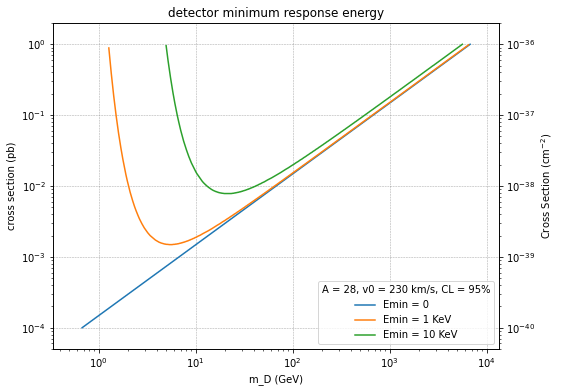

In [19]:
# detector response range
mass1, xs1 = get_limit_contour(E1 = 0) 
mass2, xs2 = get_limit_contour(E1 = 1*10**-6) 
mass3, xs3 = get_limit_contour(E1 = 10*10**-6) 

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(mass1, xs1, label='Emin = 0')
ax1.plot(mass2, xs2, label='Emin = 1 KeV')
ax1.plot(mass3, xs3, label='Emin = 10 KeV')

ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_title('detector minimum response energy')
ax1.set_xlabel('m_D (GeV)')
ax1.set_ylabel('cross section (pb)')
ax1.set_xlim(np.hstack([mass1, mass2, mass3]).min()/2, np.hstack([mass1, mass2, mass3]).max()*2)
ax1.set_ylim(np.hstack([xs1, xs2, xs3]).min()/2, np.hstack([xs1, xs2, xs3]).max()*2)


ax1.axhline(0, color='black', linewidth=0.5, linestyle="--")
ax1.axvline(0, color='black', linewidth=0.5, linestyle="--")
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# second axis
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.set_ylabel(r'Cross Section (cm$^{-2}$)')
ax2.set_ylim(ax1.get_ylim()[0] * 1e-36, ax1.get_ylim()[1] * 1e-36)

ax1.legend(title = 'A = 28, v0 = 230 km/s, CL = 95%')
plt.show()

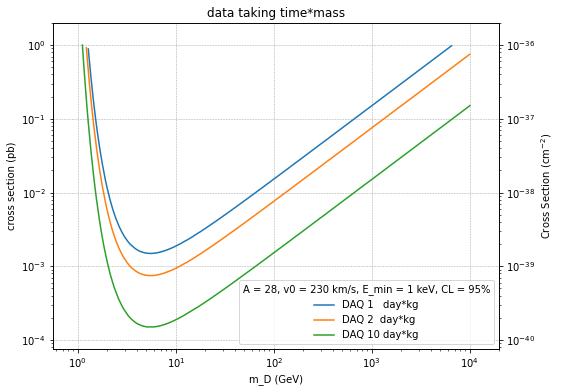

In [20]:
# DAQ time
mass1, xs1 = get_limit_contour(DAQday=1) 
mass2, xs2 = get_limit_contour(DAQday=2) 
mass3, xs3 = get_limit_contour(DAQday=10) 

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(mass1, xs1, label='DAQ 1   day*kg')
ax1.plot(mass2, xs2, label='DAQ 2  day*kg')
ax1.plot(mass3, xs3, label='DAQ 10 day*kg')

ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_title('data taking time*mass')
ax1.set_xlabel('m_D (GeV)')
ax1.set_ylabel('cross section (pb)')
ax1.set_xlim(np.hstack([mass1, mass2, mass3]).min()/2, np.hstack([mass1, mass2, mass3]).max()*2)
ax1.set_ylim(np.hstack([xs1, xs2, xs3]).min()/2, np.hstack([xs1, xs2, xs3]).max()*2)

# second axis
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.set_ylabel(r'Cross Section (cm$^{-2}$)')
ax2.set_ylim(ax1.get_ylim()[0] * 1e-36, ax1.get_ylim()[1] * 1e-36)


ax1.axhline(0, color='black', linewidth=0.5, linestyle="--")
ax1.axvline(0, color='black', linewidth=0.5, linestyle="--")
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

ax1.legend(title = 'A = 28, v0 = 230 km/s, E_min = 1 keV, CL = 95%')
plt.show()